In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots
from RaTag.thgem_tpc.coincidence_workflow import map_coincidence_extraction
from RaTag.thgem_tpc.multiiso_workflow import map_multiiso_separation

%matplotlib inline

# Initialize test run and drift properties

In [28]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run34_analysis.yaml'

bare_run = bootstrap_from_config(config_path)

Found 10 directories in RUN34_EL15k
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode0720 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode0788 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0216_Anode0816 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0252_Anode0852 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode0888 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0384_Anode0984 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1080 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1176 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1272 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1368 with 50 waveforms.
  → Bootstrapped 10 PMT Sets and 10 Alpha Sets. (Multi-Isotope: True)


In [29]:
run = map_drift_physics(bare_run, force=False)

  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0120_Anode0720'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0120_Anode0720'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0120_Anode0720'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0188_Anode0788'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0188_Anode0788'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0188_Anode0788'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0216_Anode0816'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0216_Anode0816'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0216_Anode0816'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0252_Anode0852'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0252_Anode0852'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0252_Anode0852'
  📂 Cache Hit: Loaded metada

In [47]:
run = map_alpha_events(run, force=False)


RECONSTRUCTING ALPHA ENERGIES: RUN_34
  📂 FieldScan_Gate0120_Anode0720: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0188_Anode0788: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0216_Anode0816: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0252_Anode0852: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0288_Anode0888: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0384_Anode0984: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0480_Anode1080: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0576_Anode1176: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0672_Anode1272: Loaded 'alpha_energies' arrays from disk
  📂 FieldScan_Gate0768_Anode1368: Loaded 'alpha_energies' arrays from disk


In [ ]:
run = 

In [45]:
runa = map_multiiso_separation(runa)


SEPARATING MULTI-ISOTOPE SETS: RUN_34


In [40]:
run.alpha_sets[0]

SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN34_EL15k/FieldScan_Gate0120_Anode0720
  filenames = <50 files, 47200 waveforms, FastFrame(944 frames/file)>
  multiiso = True
  ff = True
  nframes = 944
  gate = 120
  anode = 720

  Missing:
    target_isotope, sampling_rate, n_alpha_energies, calib_a, calib_b, calib_c, calib_order, mean_energy_resolution, isotope_ranges_V, isotope_ranges_E

# Check first set results

In [27]:
set0 = run.sets[9]
set0

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN34_EL15k/FieldScan_Gate0768_Anode1368
  filenames = <50 files, 47200 waveforms, FastFrame(944 frames/file)>
  multiiso = True
  ff = True
  nframes = 944
  gate = 768
  anode = 1368
  drift_field = 1600.0
  EL_field = 15000.0
  red_drift_field = 6.561
  red_EL_field = 61.508
  speed_drift = 2.057
  time_drift = 2.334
  t_s1 = -4.846
  t_s1_std = 0.742
  t_s2_start = 4.302
  t_s2_start_std = 1.855
  t_s2_end = 4.96
  t_s2_end_std = 3.077
  n_areas_recoil = 49350
  area_s2_mean = 1.705
  area_s2_sigma = 1.311
  area_s2_ci95 = 0.138
  area_s2_fit_success = True

  Missing:
    target_isotope, sampling_rate, diffusion_coefficient, baseline_median, baseline_std, filtered_drift_time, s2_background_bound

In [10]:
from RaTag.io.file_ops import load_s2areas

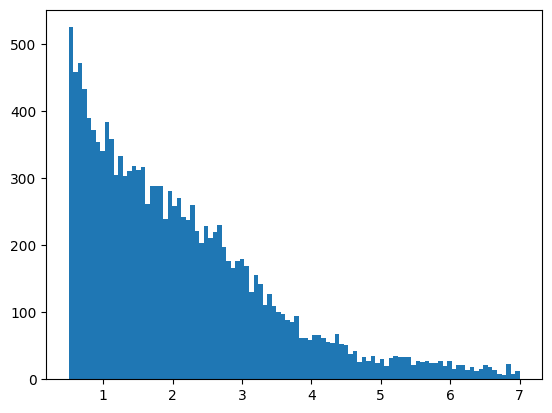

In [22]:
s2_areas = load_s2areas(set0)
plt.hist(s2_areas.areas, bins=100, range=(0.5, 7));